In [1]:
from optimal.RobotController import RobotController
from optimal.RobotMujocoModel import RobotMujocoModel
from optimal.RobotPinocchioModel import RobotPinocchioModel
from optimal.configuration import UR10_sandbox
import numpy as np
import crocoddyl

config = UR10_sandbox
robot_mj_model = RobotMujocoModel(config.mjcf_path, config.list_of_joints)
robot_pin_model = RobotPinocchioModel(config.urdf_path, config.list_of_joints)
controller = RobotController(robot_pin_model)

DT = robot_mj_model.model.opt.timestep
nq = len(config.list_of_joints)
print(f"Timestep: {DT*1000:.2f} ms  |  DOF: {nq}")


Timestep: 2.00 ms  |  DOF: 6


[0 1 2 3 4 5]


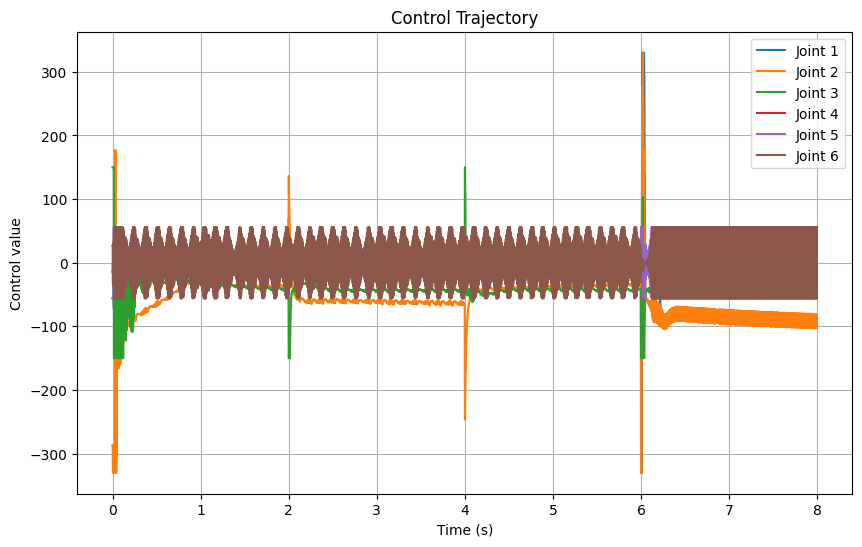

In [6]:
path = [robot_pin_model.current_q(),
    np.array([-1.8, -1.8, 1.8, -1.8, -1.8, 1.8]),
    np.array([-1.8, -1.2, 1.5, -1.8, -1.8, 1.8]),
    np.array([-1.8, -1.8, 1.8, -1.8, -1.8, 1.8]),
    np.array([ 0.4, -0.4, 1.5, -0.8,  1.5,  0.5])]

T_mpc   = 10    # OCP horizon (steps)
N_steps = 1000   # simulation steps per segment

# mpc_visualize passes x_start = [q, v] (len 2*nq); slice to q only for compute_control.
# compute_control returns (xs, us); [1] selects us so mpc_visualize can index u[0, :nu].
func = lambda q_start, q_target: controller.compute_control(
    q_start, q_target,
    T=T_mpc, DT=DT,
    option="crocoddyl", solver=crocoddyl.SolverBoxFDDP,
    track_weight=1e2, ctrl_weight=1, terminal_weight=1e5,
    kp=config.closed_loop_kp, kd=config.closed_loop_kd)

robot_mj_model.reset()
print(robot_mj_model.u_indices)

xs_mpc, us_mpc = robot_mj_model.mpc_visualize(
    path,
    compute_control=func,
    segment_lengths=[N_steps] * (len(path) - 1),
    dt=DT,
    hold=False,
)
robot_mj_model.plot_controls(us_mpc, dt=DT)
# print(f"Collected {len(xs_mpc)} states, {len(us_mpc)} controls.")


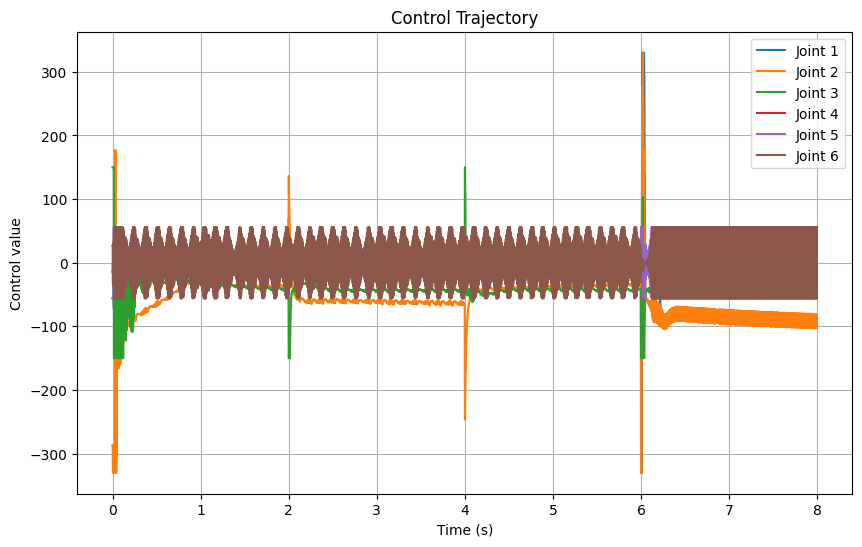

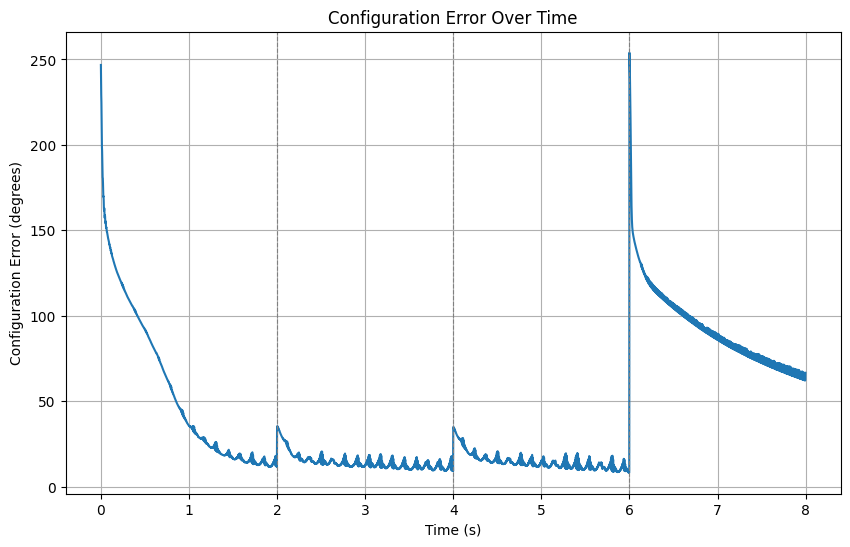

In [7]:
robot_mj_model.plot_controls(us_mpc, dt=DT)
robot_mj_model.plot_error(xs_mpc, path[1:], segment_lengths=[N_steps] * (len(path) - 1), dt=DT)


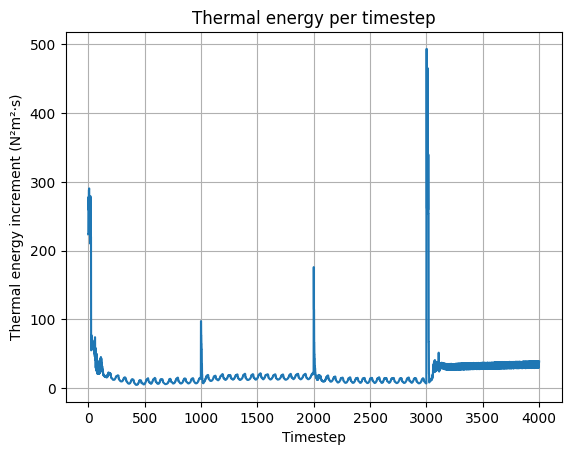

Thermal energy: 87512.37137857258


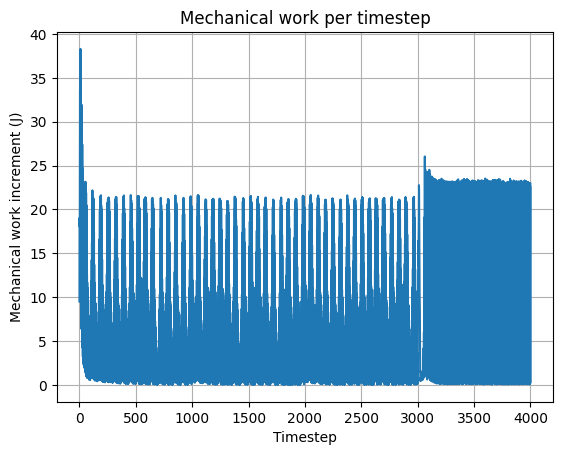

Mechanical work: 29684.02977640357


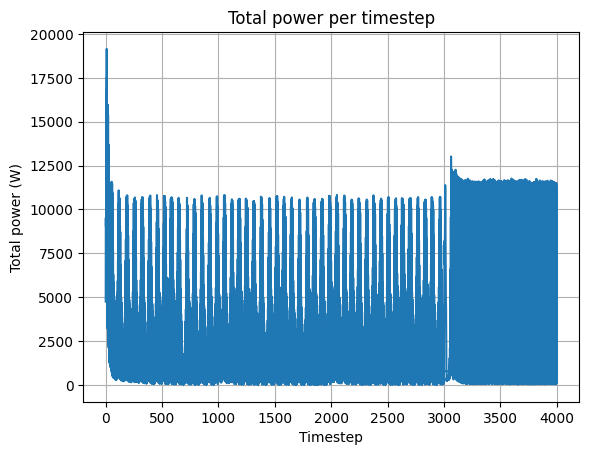

Peak power: 19147.718553235878


In [9]:
from optimal.metrics import thermal_energy, mechanical_work, peak_power

E_th  = thermal_energy(us_mpc, DT, True)
print("Thermal energy:", E_th)
E_mech = mechanical_work(us_mpc, xs_mpc, DT, True)
print("Mechanical work:", E_mech)
P_peak = peak_power(us_mpc, xs_mpc, True)
print("Peak power:", P_peak)